In [1]:
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
import tensorflow as tf
from sklearn.metrics import classification_report,confusion_matrix

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import tensorflow as tf
from tensorflow.keras import layers as L
import keras
from keras.layers import *

## Data Preprocessing

In [3]:
DIRECTORY = r'/kaggle/input/covid-ieee-train-test-split/COVID_IEEE Train Test Split/train'
CATEGORIES = ['covid', 'normal', 'virus']
IMG_SIZE = 224
train_data = []

In [4]:
for category in CATEGORIES:
    folder = os.path.join(DIRECTORY,category)
    #print(folder)
    label = CATEGORIES.index(category)
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        #print(img_path)
        img_arr = cv2.imread(img_path)
        img_arr = cv2.resize(img_arr, (IMG_SIZE, IMG_SIZE))
        #plt.imshow(img_arr)
        #break
        train_data.append([img_arr, label])

In [5]:
len(train_data)

1457

In [6]:
random.shuffle(train_data)

In [7]:
X_train = []
y_train = []

for features, labels in train_data:
    X_train.append(features)
    y_train.append(labels)

In [8]:
DIRECTORY = r'/kaggle/input/covid-ieee-train-test-split/COVID_IEEE Train Test Split/test'
CATEGORIES = ['covid', 'normal', 'virus']
IMG_SIZE = 224
test_data = []

In [9]:
for category in CATEGORIES:
    folder = os.path.join(DIRECTORY,category)
    #print(folder)
    label = CATEGORIES.index(category)
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        #print(img_path)
        img_arr = cv2.imread(img_path)
        img_arr = cv2.resize(img_arr, (IMG_SIZE, IMG_SIZE))
        #plt.imshow(img_arr)
        #break
        test_data.append([img_arr, label])

In [10]:
len(test_data)

366

In [11]:
X_test = []
y_test = []

for features, labels in test_data:
    X_test.append(features)
    y_test.append(labels)

In [12]:
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

In [13]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1457, 224, 224, 3), (366, 224, 224, 3), (1457,), (366,))

# Model

In [14]:
data_augmentation = keras.Sequential(
    [
        Normalization(),
        RandomFlip("horizontal"),
        RandomRotation(factor=0.02),
        RandomZoom(
            height_factor=0.2, width_factor=0.2
        ),
        RandomContrast(0.2),
        RandomBrightness(0.2)
    ],
    name="data_augmentation",
)

In [15]:
class SpatialAttentionModule(tf.keras.layers.Layer):
    def __init__(self, kernel_size=3):
        '''
        paper: https://arxiv.org/abs/1807.06521
        code: https://gist.github.com/innat/99888fa8065ecbf3ae2b297e5c10db70
        '''
        super(SpatialAttentionModule, self).__init__()
        self.conv1 = tf.keras.layers.Conv2D(64, kernel_size=kernel_size, 
                                            use_bias=False, 
                                            kernel_initializer='he_normal',
                                            strides=1, padding='same', 
                                            activation=tf.nn.relu)
        self.conv2 = tf.keras.layers.Conv2D(32, kernel_size=kernel_size, 
                                            use_bias=False, 
                                            kernel_initializer='he_normal',
                                            strides=1, padding='same', 
                                            activation=tf.nn.relu)
        self.conv3 = tf.keras.layers.Conv2D(16, kernel_size=kernel_size, 
                                            use_bias=False, 
                                            kernel_initializer='he_normal',
                                            strides=1, padding='same', 
                                            activation=tf.nn.relu)
        self.conv4 = tf.keras.layers.Conv2D(1, kernel_size=kernel_size,  
                                            use_bias=False,
                                            kernel_initializer='he_normal',
                                            strides=1, padding='same', 
                                            activation=tf.math.sigmoid)

    def call(self, inputs):
        avg_out = tf.reduce_mean(inputs, axis=3)
        max_out = tf.reduce_max(inputs,  axis=3)
        x = tf.stack([avg_out, max_out], axis=3) 
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return self.conv4(x)
    

class ChannelAttentionModule(tf.keras.layers.Layer):
    def __init__(self, ratio=8):
        '''
        paper: https://arxiv.org/abs/1807.06521
        code: https://gist.github.com/innat/99888fa8065ecbf3ae2b297e5c10db70
        '''
        super(ChannelAttentionModule, self).__init__()
        self.ratio = ratio
        self.gapavg = tf.keras.layers.GlobalAveragePooling2D()
        self.gmpmax = tf.keras.layers.GlobalMaxPooling2D()
        
    def build(self, input_shape):
        self.conv1 = tf.keras.layers.Conv2D(input_shape[-1]//self.ratio, 
                                            kernel_size=1, 
                                            strides=1, padding='same',
                                            use_bias=True, activation=tf.nn.relu)
    
        self.conv2 = tf.keras.layers.Conv2D(input_shape[-1], 
                                            kernel_size=1, 
                                            strides=1, padding='same',
                                            use_bias=True, activation=tf.nn.relu)
        super(ChannelAttentionModule, self).build(input_shape)

    def call(self, inputs):
        # compute gap and gmp pooling 
        gapavg = self.gapavg(inputs)
        gmpmax = self.gmpmax(inputs)
        gapavg = tf.keras.layers.Reshape((1, 1, gapavg.shape[1]))(gapavg)   
        gmpmax = tf.keras.layers.Reshape((1, 1, gmpmax.shape[1]))(gmpmax)   
        # forward passing to the respected layers
        gapavg_out = self.conv2(self.conv1(gapavg))
        gmpmax_out = self.conv2(self.conv1(gmpmax))
        return tf.math.sigmoid(gapavg_out + gmpmax_out)
    
    def get_output_shape_for(self, input_shape):
        return self.compute_output_shape(input_shape)

    def compute_output_shape(self, input_shape):
        output_len = input_shape[3]
        return (input_shape[0], output_len)

In [16]:
def casa_module(x):
    x_ca = ChannelAttentionModule()(x)
    x_ca_out = Multiply()([x_ca, x])
    x_sa = SpatialAttentionModule()(x)
    x_sa_out = Multiply()([x_sa, x])
    # Concatenate
    x_casa = Concatenate()([x_ca_out, x_sa_out])
    return x_casa

In [17]:
def inverted_residual_block(inputs, num_filters, strides=1, expansion_ratio=1):
    # point-wise conv
    x = L.Conv2D(filters=expansion_ratio*inputs.shape[-1],
                 kernel_size=1,
                 padding='same',
                 use_bias=False)(inputs)
    x = L.BatchNormalization()(x)
    x = L.Activation('swish')(x)
    
    # depth-wise conv
    x = L.DepthwiseConv2D(kernel_size=3,
                          strides=strides,
                          padding='same',
                          use_bias=False)(x)
    x = L.BatchNormalization()(x)
    x = L.Activation('swish')(x)
    
    # point-wise conv
    x = L.Conv2D(filters=num_filters,
                 kernel_size=1,
                 padding='same',
                 use_bias=False)(x)
    x = L.BatchNormalization()(x)
    
    # Residual Connection
    if strides == 1 and (inputs.shape == x.shape):
        return L.Add()([inputs, x])
    return x
    

In [52]:
inputs = Input((224,224,3))
#x = ZeroPadding2D((3,3))(inputs)

x = SeparableConv2D(64, (3,3), strides=(2,2))(inputs)
x = BatchNormalization(axis=3)(x)
x = Activation('relu')(x)

x = SeparableConv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = inverted_residual_block(x, 64, strides=1, expansion_ratio=2)

x1 = MaxPooling2D((2,2))(x)
x2 = casa_module(x)
x2 = MaxPooling2D((2,2))(x)
x = Concatenate()([x1, x2])


x = SeparableConv2D(128, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = SeparableConv2D(256, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = SeparableConv2D(256, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

In [53]:
cnn = keras.Model(inputs, x)

In [54]:
cnn.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 separable_conv2d_17 (Separable  (None, 111, 111, 64  283        ['input_8[0][0]']                
 Conv2D)                        )                                                                 
                                                                                                  
 batch_normalization_13 (BatchN  (None, 111, 111, 64  256        ['separable_conv2d_17[0][0]']    
 ormalization)                  )                                                           

In [55]:
model = tf.keras.Sequential([
    InputLayer((224,224,3)),
    data_augmentation,
    cnn,
    #Flatten(),
    GlobalAveragePooling2D(),
    #BatchNormalization(),
    Dropout(0.6),#0.75
    Dense(512, activation='relu'),
    Dropout(0.5),#0.5
    Dense(256, activation='relu'),
    #Dropout(0.2),#0.5
    Dense(128, activation='relu'),
    #Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

In [56]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 data_augmentation (Sequenti  (None, 224, 224, 3)      7         
 al)                                                             
                                                                 
 model_3 (Functional)        (None, 1, 1, 256)         144027    
                                                                 
 global_average_pooling2d_7   (None, 256)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_6 (Dropout)         (None, 256)               0         
                                                                 
 dense_15 (Dense)            (None, 512)               131584    
                                                                 
 dropout_7 (Dropout)         (None, 512)              

In [58]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [59]:
class_weights = {0:1.1347,
                 1:0.9095,
                 2:0.9811}

In [60]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

In [61]:
filepath = "/kaggle/working/Max_CASA_IRB_{epoch:02d}_{val_accuracy:.2f}.h5"
checkpoint = ModelCheckpoint(filepath, monitor="val_accuracy",
                             verbose=1, save_best_only=True,
                             mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy',factor=1e-1, patience=10,
                              verbose=1, min_lr = 0.00005)
callbacks = [checkpoint, reduce_lr]

In [62]:
history = model.fit(X_train, y_train, 
                    validation_data=[X_test, y_test],
                    class_weight=class_weights,
                    callbacks=callbacks,
                    epochs=250, batch_size=32)

Epoch 1/250
45/46 [============================>.] - ETA: 0s - loss: 1.0407 - accuracy: 0.4340
Epoch 1: val_accuracy improved from -inf to 0.29508, saving model to /kaggle/working/Max_CASA_IRB_01_0.30.h5
46/46 [==============================] - 11s 82ms/step - loss: 1.0383 - accuracy: 0.4372 - val_loss: 1.1059 - val_accuracy: 0.2951 - lr: 0.0010
Epoch 2/250
45/46 [============================>.] - ETA: 0s - loss: 0.8393 - accuracy: 0.5938
Epoch 2: val_accuracy did not improve from 0.29508
46/46 [==============================] - 3s 70ms/step - loss: 0.8370 - accuracy: 0.5944 - val_loss: 1.7568 - val_accuracy: 0.2951 - lr: 0.0010
Epoch 3/250
45/46 [============================>.] - ETA: 0s - loss: 0.6429 - accuracy: 0.7021
Epoch 3: val_accuracy did not improve from 0.29508
46/46 [==============================] - 3s 73ms/step - loss: 0.6405 - accuracy: 0.7035 - val_loss: 1.8954 - val_accuracy: 0.2951 - lr: 0.0010
Epoch 4/250
45/46 [============================>.] - ETA: 0s - loss: 0.489

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])


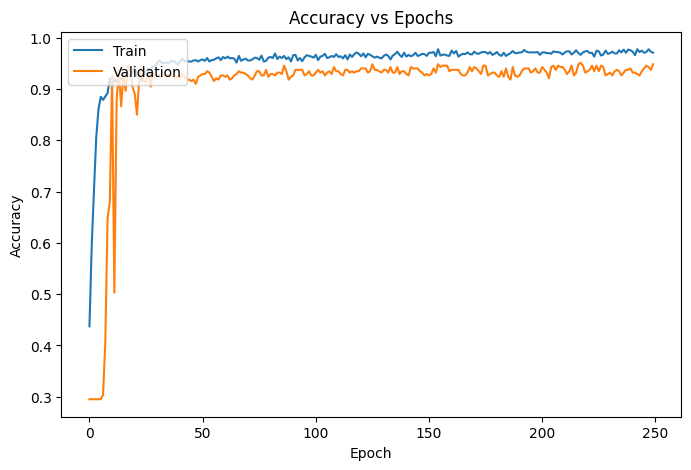

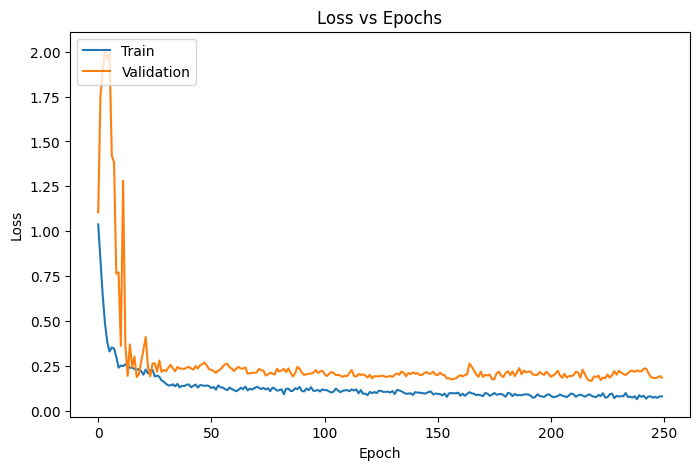

In [63]:
print(history.history.keys())

#  "Accuracy"
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('acc_95_MaxCaSaIRB.png', dpi=1200)
plt.show()

# "Loss"
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('loss_95_MaxCaSaIRB.png', dpi=1200)
plt.show()

## Performance Evaluation

In [64]:
re_model = tf.keras.models.load_model('/kaggle/working/Max_CASA_IRB_218_0.95.h5',
                                custom_objects={'ChannelAttentionModule':ChannelAttentionModule,
                                                'SpatialAttentionModule':SpatialAttentionModule})

In [65]:
re_model.evaluate(X_test, y_test)

12/12 [==============================] - 1s 22ms/step - loss: 0.1689 - accuracy: 0.9508


[0.16893461346626282, 0.9508196711540222]

In [66]:
y_pred = re_model.predict(X_test)

12/12 [==============================] - 0s 20ms/step


In [67]:
y_pred = np.argmax(y_pred, axis=1)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2,

In [68]:
y_true = y_test

In [69]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       108
           1       0.95      0.93      0.94       134
           2       0.94      0.95      0.94       124

    accuracy                           0.95       366
   macro avg       0.95      0.95      0.95       366
weighted avg       0.95      0.95      0.95       366



In [70]:
print(confusion_matrix(y_true, y_pred))

[[105   2   1]
 [  2 125   7]
 [  1   5 118]]
